#  Detectron2 Mask R-CNN Trainer

This notebook provides a complete and professional pipeline for fine-tuning the **Detectron2 Mask R-CNN (R50-FPN 3x)** model on the custom microscopic rock cutting dataset.

###  Model Overview
The model `maskrcnnR50FPN3x` is obtained from the **Detectron2 Model Zoo**.
- **100% Pretrained**: The ResNet-50 backbone is pretrained on ImageNet, and the entire Mask R-CNN architecture is pretrained on the COCO instance segmentation dataset (80 categories).
- **Fine-tuning**: We fine-tune this robust model on our specific 6-7 rock classes, exploiting generalized visual features which significantly accelerates convergence and improves performance despite the smaller dataset size.

###  Prerequisites
Detectron2 specifically requires **COCO JSON format**.
If your dataset is currently in YOLO format, you must first convert it using the `convertyolotococo.py` script located in `scripts/datapreprocessing/singlemodel/`.

---

## 1. Environment Setup
Install the required PyTorch and Detectron2 libraries.

In [1]:
import os

# Clean up
!pip uninstall -y torch torchvision torchaudio detectron2
!pip cache purge

# Install setuptools first (critical for pkg_resources)
!pip install setuptools

# Install latest compatible nightly builds from CUDA 12.8 index
!pip install --pre torch torchvision --index-url https://download.pytorch.org/whl/nightly/cu128

# Verify
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Compute capability: {torch.cuda.get_device_capability(0)}")

# Set CUDA architecture for Detectron2 compilation
os.environ["TORCH_CUDA_ARCH_LIST"] = "8.0;8.6;9.0;9.0a;12.0;12.0+PTX"

!pip install ninja
!pip install 'git+https://github.com/facebookresearch/detectron2.git' --no-build-isolation --no-cache-dir --force-reinstall
!pip install opencv-python matplotlib

Found existing installation: torch 2.12.0.dev20260407+cu128
Uninstalling torch-2.12.0.dev20260407+cu128:
  Successfully uninstalled torch-2.12.0.dev20260407+cu128
Found existing installation: torchvision 0.27.0.dev20260407+cu128
Uninstalling torchvision-0.27.0.dev20260407+cu128:
  Successfully uninstalled torchvision-0.27.0.dev20260407+cu128
Found existing installation: detectron2 0.6
Uninstalling detectron2-0.6:
  Successfully uninstalled detectron2-0.6
Files removed: 20 (1139.0 MB)
Directories removed: 0
Looking in indexes: https://download.pytorch.org/whl/nightly/cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 10.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 16.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 MB 33.8 MB/s  0:00:27m0:00:0100:01
  Attempting uninstall: setuptools
    Found existing installation: setuptools 82.0.1
    Uninstalling setuptools-82.0.1:
      Successfully uninstalled setuptools-82.0.1

In [2]:
import torch
import detectron2
from detectron2.utils.logger import setup_logger

setup_logger()
print(f"PyTorch Version: {torch.__version__}, CUDA Available: {torch.cuda.is_available()}")
print(f"Detectron2 Version: {detectron2.__version__}")

PyTorch Version: 2.12.0.dev20260407+cu128, CUDA Available: True
Detectron2 Version: 0.6


## 2. Dataset Registration
Register the mapped COCO datasets for `train` and `val` configurations.

In [3]:
import os
from detectron2.data.datasets import register_coco_instances

# Ensure you have converted YOLO formats properly and updated paths here.
# Example paths, replace with actual converted absolute dataset root paths.
DATASET_ROOT = "/home/praktikan/projects/DwiAnggara/Datasets/Batch3and4_COCO"  

train_json = os.path.join(DATASET_ROOT, "train/annotations/instances_default.json")
train_imgs = os.path.join(DATASET_ROOT, "train/images")

val_json = os.path.join(DATASET_ROOT, "val/annotations/instances_default.json")
val_imgs = os.path.join(DATASET_ROOT, "val/images")

try:
    register_coco_instances("rock_train", {}, train_json, train_imgs)
    register_coco_instances("rock_val", {}, val_json, val_imgs)
    print("Datasets registered successfully.")
except Exception as e:
    print(f"Warning or Registration Error: {e}")

Datasets registered successfully.


## 3. Training Configuration
Define the custom trainer to initialize the parameters for Mask R-CNN, including batch sizes linearly scaling across memory availability.

In [4]:
!pip install setuptools

In [6]:
# Downgrade setuptools to a compatible version (<82)
!pip install 'setuptools<82' --force-reinstall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 885.1 kB/s  0:00:01 eta 0:00:01
  Attempting uninstall: setuptools
    Found existing installation: setuptools 82.0.1
    Uninstalling setuptools-82.0.1:
      Successfully uninstalled setuptools-82.0.1


In [7]:
from detectron2.config import get_cfg
from detectron2 import model_zoo

cfg = get_cfg()

# Load baseline Mask R-CNN config
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))

# Pretrained model checkpoint URL
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")

# Assign dataset configurations
cfg.DATASETS.TRAIN = ("rock_train",)
cfg.DATASETS.TEST = ("rock_val",)

# Multiprocessing settings
cfg.DATALOADER.NUM_WORKERS = 4

# Batch configurations (Modify IMS_PER_BATCH considering your GPU VRAM)
cfg.SOLVER.IMS_PER_BATCH = 4       # Increase to 8 or 16 if >= 24GB VRAM
cfg.SOLVER.BASE_LR = 0.0001        # Specifically lowered for class-imbalanced rock instances
cfg.SOLVER.MAX_ITER = 3000         # Total iterations, usually 1000-5000 is adequate
cfg.SOLVER.STEPS = []              # Custom decay steps if needed (e.g., (2000, 2500))

# Architecture configs
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 512  # RoI bounding box batch processing constraints
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 6             # Update to 6 specific rock classes
cfg.MODEL.ROI_MASK_HEAD.BOUNDARY_PRECISION = True # Better delineations for irregular structures

cfg.INPUT.RANDOM_FLIP = "horizontal"          # Built-in robust augmentation mechanisms

# Save configurations
import string, random
random_slug = "".join(random.choices(string.ascii_letters + string.digits, k=6))
RUNNER_NAME = f"Detectron2_Batch4_{random_slug}"
cfg.OUTPUT_DIR = f"./models/{RUNNER_NAME}"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

/home/praktikan/miniconda3/envs/magangpdu-dwi/lib/python3.10/site-packages/detectron2/model_zoo/model_zoo.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 4. Run Training Pipeline
Initialize the `DefaultTrainer`, load the previously processed configs, and map the outputs appropriately.

In [8]:
from detectron2.engine import DefaultTrainer
import logging
from detectron2.evaluation import inference_on_dataset
from detectron2.data import build_detection_test_loader
import os

class CustomTrainer(DefaultTrainer):
    @classmethod
    def build_evaluator(cls, cfg, dataset_name, output_folder=None):
        from detectron2.evaluation import COCOEvaluator
        if output_folder is None:
            output_folder = os.path.join(cfg.OUTPUT_DIR, "inference")
        os.makedirs(output_folder, exist_ok=True)
        # Natively compute overall and per-class AP/AR metrics against validation splits
        # to closely monitor minority class performance.
        return COCOEvaluator(dataset_name, output_dir=output_folder)

print(f"\n{'='*50}")
print(f" INITIATING MASK R-CNN TRAINING RUN")
print(f"{'='*50}\n")

trainer = CustomTrainer(cfg)
# False means it initializes from baseline pretrained weights
trainer.resume_or_load(resume=False)

# Execute the main training loop
trainer.train()

print(f"\n{'='*50}")
print(f"  PER-CLASS EVALUATION (MINORITY CLASS MONITORING)")
print(f"{'='*50}")
evaluator = CustomTrainer.build_evaluator(cfg, "rock_val")
val_loader = build_detection_test_loader(cfg, "rock_val")
eval_results = inference_on_dataset(trainer.model, val_loader, evaluator)
print(eval_results)
print(f"{'='*50}\n")
print(f"\n Training sequence completed perfectly. Best checkpoints preserved at {cfg.OUTPUT_DIR}.")


 INITIATING MASK R-CNN TRAINING RUN

[04/21 10:57:48 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, e

Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (7, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (7,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (24, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (24,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.mask_head.predictor.weight' to the model due to incompatible shapes: (80, 256, 1, 1) in the checkpoint but (6, 256, 1, 1) 

[04/21 10:57:48 d2.engine.train_loop]: Starting training from iteration 0


/home/praktikan/miniconda3/envs/magangpdu-dwi/lib/python3.10/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4382.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0421 10:57:49.216000 1107665 site-packages/torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


[04/21 10:57:56 d2.utils.events]:  eta: 0:14:19  iter: 19  total_loss: 5.227  loss_cls: 2.094  loss_box_reg: 0.6718  loss_mask: 0.695  loss_rpn_cls: 1.586  loss_rpn_loc: 0.1807    time: 0.3609  last_time: 0.2881  data_time: 0.0871  last_data_time: 0.0160   lr: 1.9981e-06  max_mem: 5085M
[04/21 10:58:04 d2.utils.events]:  eta: 0:14:08  iter: 39  total_loss: 5.045  loss_cls: 2.034  loss_box_reg: 0.6802  loss_mask: 0.6944  loss_rpn_cls: 1.504  loss_rpn_loc: 0.1829    time: 0.3730  last_time: 0.2691  data_time: 0.1085  last_data_time: 0.0019   lr: 3.9961e-06  max_mem: 5085M
[04/21 10:58:10 d2.utils.events]:  eta: 0:13:46  iter: 59  total_loss: 4.407  loss_cls: 1.926  loss_box_reg: 0.7144  loss_mask: 0.6927  loss_rpn_cls: 0.8762  loss_rpn_loc: 0.1681    time: 0.3542  last_time: 0.2826  data_time: 0.0438  last_data_time: 0.0040   lr: 5.9941e-06  max_mem: 5085M
[04/21 10:58:16 d2.utils.events]:  eta: 0:13:42  iter: 79  total_loss: 3.88  loss_cls: 1.8  loss_box_reg: 0.6656  loss_mask: 0.6903  

## 5. Visual Testing / Fast Inference (Optional)

[04/21 11:17:25 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./models/Detectron2_Batch4_5Cf9M7/model_final.pth ...
Running predictor algorithms on: /home/praktikan/projects/DwiAnggara/Datasets/Batch3and4_COCO/val/images/PIC-0025.jpg


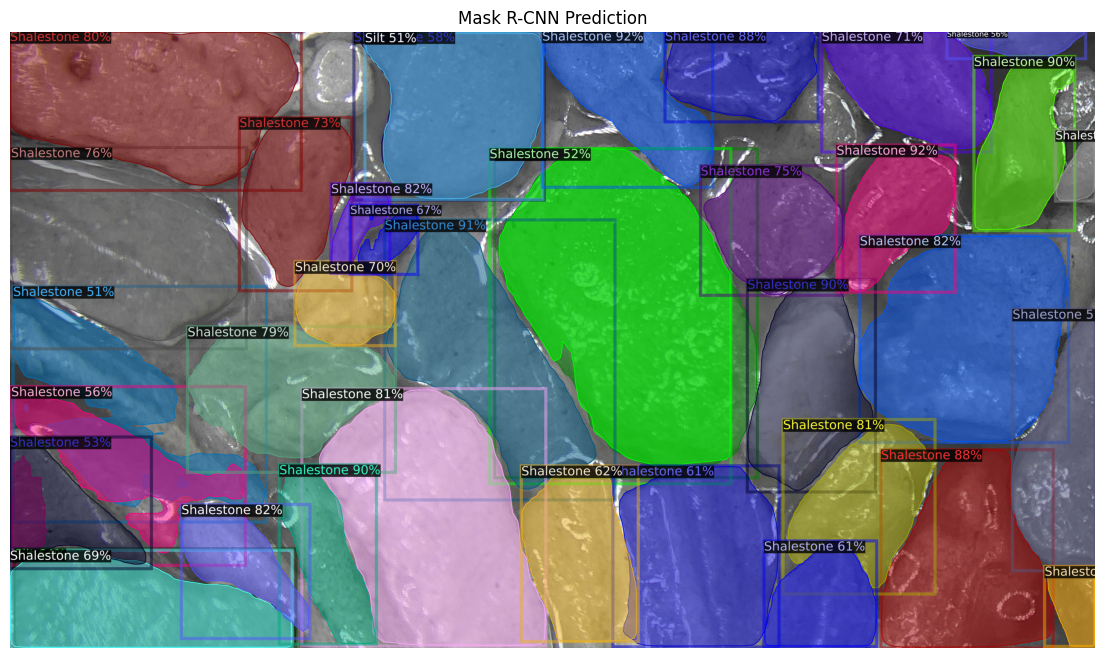

In [11]:
from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
import cv2
import matplotlib.pyplot as plt
import random
import os

def test_inference(test_image_dir):
    weights_path = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
    if not os.path.exists(weights_path):
        print(f"[Error] Checkpoint '{weights_path}' not found!")
        print("Please ensure that the training cell (Cell 4) finishes all iterations successfully before running inference.")
        return
        
    cfg.MODEL.WEIGHTS = weights_path
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5   # Target 50% inference threshold strictly for visual rendering
    predictor = DefaultPredictor(cfg)

    images = [img for img in os.listdir(test_image_dir) if img.endswith((".jpg", ".png"))]
    if not images:
        print("No images for testing available.")
        return
        
    sample_img = os.path.join(test_image_dir, random.choice(images))
    im = cv2.imread(sample_img)
    
    print(f"Running predictor algorithms on: {sample_img}")
    outputs = predictor(im)
    
    v = Visualizer(im[:, :, ::-1], MetadataCatalog.get("rock_val"), scale=1.2)
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
    
    plt.figure(figsize=(14, 10))
    plt.imshow(out.get_image())
    plt.axis("off")
    plt.title("Mask R-CNN Prediction")
    plt.show()

# Ensure execution is called properly when checking local runs
test_inference(val_imgs)